# 5. Класифікатор kNN (k-найближчих сусідів)

Алгоритм kNN класифікує об'єкт за "голосуванням" його k найближчих сусідів у просторі ознак. Це лінивий алгоритм (lazy learner) -- він не будує модель, а зберігає всі тренувальні дані і використовує їх при передбаченні.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

df = pd.read_csv('data_processed.csv')
X = df[['age', 'education-num', 'relationship']]
y = df['income']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Тренувальна вибірка: {X_train.shape[0]}, Тестова: {X_test.shape[0]}')

Тренувальна вибірка: 39073, Тестова: 9769


## Масштабування ознак

kNN обчислює евклідову відстань між точками. Якщо ознаки мають різні масштаби (`age` 17-90 vs `relationship` 0-5), то ознака з більшим діапазоном домінуватиме. `StandardScaler` приводить всі ознаки до середнього 0 та стандартного відхилення 1.

In [2]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Середнє (train):', np.round(X_train_scaled.mean(axis=0), 2))
print('Стд. відх. (train):', np.round(X_train_scaled.std(axis=0), 2))

Середнє (train): [-0. -0.  0.]
Стд. відх. (train): [1. 1. 1.]


Accuracy: 0.8085

              precision    recall  f1-score   support

       <=50K       0.87      0.88      0.88      7431
        >50K       0.61      0.57      0.59      2338

    accuracy                           0.81      9769
   macro avg       0.74      0.73      0.73      9769
weighted avg       0.80      0.81      0.81      9769



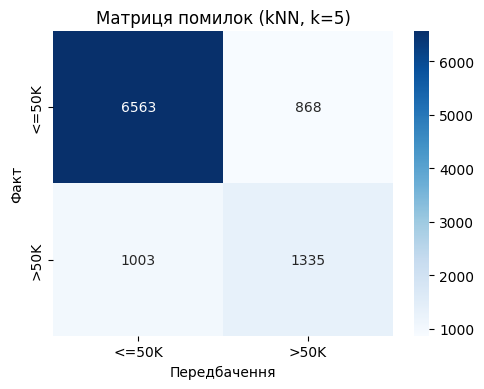

In [3]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)

print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}\n')
print(classification_report(y_test, y_pred, target_names=['<=50K', '>50K']))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['<=50K', '>50K'], yticklabels=['<=50K', '>50K'])
plt.xlabel('Передбачення')
plt.ylabel('Факт')
plt.title('Матриця помилок (kNN, k=5)')
plt.tight_layout()
plt.show()

## Підбір гіперпараметрів

Основний гіперпараметр -- кількість сусідів `k`. Мале k веде до перенавчання, велике -- до недонавчання. Також порівняємо зважування: `uniform` (всі рівні) та `distance` (ближчі важливіші).

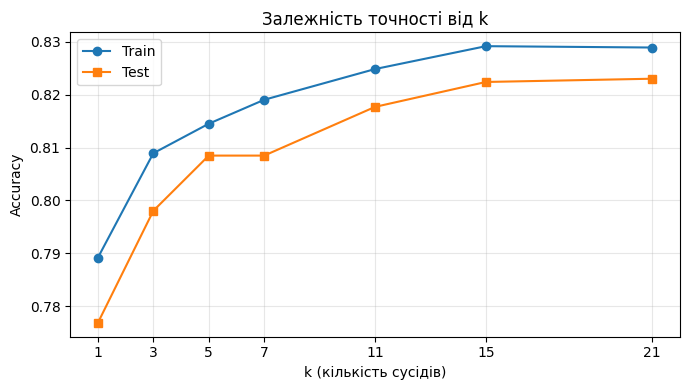

Найкращий k = 21 (accuracy = 0.8230)


In [4]:
k_values = [1, 3, 5, 7, 11, 15, 21]
train_acc, test_acc = [], []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    train_acc.append(accuracy_score(y_train, model.predict(X_train_scaled)))
    test_acc.append(accuracy_score(y_test, model.predict(X_test_scaled)))

plt.figure(figsize=(7, 4))
plt.plot(k_values, train_acc, 'o-', label='Train')
plt.plot(k_values, test_acc, 's-', label='Test')
plt.xlabel('k (кількість сусідів)')
plt.ylabel('Accuracy')
plt.title('Залежність точності від k')
plt.xticks(k_values)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_k = k_values[np.argmax(test_acc)]
print(f'Найкращий k = {best_k} (accuracy = {max(test_acc):.4f})')

In [5]:
results = []
for w in ['uniform', 'distance']:
    model = KNeighborsClassifier(n_neighbors=best_k, weights=w)
    model.fit(X_train_scaled, y_train)
    acc = accuracy_score(y_test, model.predict(X_test_scaled))
    results.append({'k': best_k, 'weights': w, 'accuracy': round(acc, 4)})

results_df = pd.DataFrame(results)
print('Порівняння стратегій зважування:')
print(results_df.to_string(index=False))

Порівняння стратегій зважування:
 k  weights  accuracy
21  uniform    0.8230
21 distance    0.8205


## Висновки

**Інтуїтивне пояснення:** З трьома ознаками kNN працює добре -- він знаходить людей, схожих за віком, рівнем освіти та сімейною роллю. Молоді неодружені люди з низькою освітою групуються разом у категорії <=50K, а старші одружені з високою освітою -- у >50K.

**Переваги:**
- Простий та інтуїтивно зрозумілий -- не потребує побудови моделі
- Добре працює з малою кількістю ознак (3 ознаки -- ідеальний випадок для kNN)

**Недоліки:**
- Повільний на великих даних -- при передбаченні обчислює відстань до кожної точки
- Обов'язкове масштабування -- чутливий до різних діапазонів ознак
- Погано працює з великою кількістю ознак ("прокляття розмірності")